# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os
from statsmodels.tsa.seasonal import seasonal_decompose

OUTPUT_PATH_figures = "/Users/chamika/Desktop/git/machine_learning/Question_2/outputs/figures/"
DATA_PATH_raw    = "/Users/chamika/Desktop/git/machine_learning/Question_2/data/raw/"
DATA_PATH_processed    = "/Users/chamika/Desktop/git/machine_learning/Question_2/data/processed/"

# Download and Inspect

In [2]:
# Cell 1: One-time download 

df_raw = yf.download("^GSPC", start="2015-01-01", end="2025-01-01", auto_adjust=True)

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)
df_raw.to_csv(os.path.join(DATA_PATH_raw, "sp500_raw_2015_2025.csv"))

[*********************100%***********************]  1 of 1 completed


In [3]:
# Cell 2: Load raw data — analysis starts here
df = pd.read_csv(
    os.path.join(DATA_PATH_raw, "sp500_raw_2015_2025.csv"),
    index_col=0,
    parse_dates=True
)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (2516, 5)
Date range: 2015-01-02 to 2024-12-31
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


### Data source note:

Daily S&P 500 index data (ticker ^GSPC) was obtained from Yahoo Finance using the yfinance Python library. The dataset spans 1 January 2015 to 31 December 2024, giving approximately 2,515 trading-day observations at daily frequency. Each record contains open, high, low, close, and volume values, with prices adjusted for splits and dividends (auto_adjust=True). The S&P 500 tracks ~500 of the largest US-listed companies and is a standard benchmark series in the forecasting literature.

This study uses daily S&P 500 index data (ticker ^GSPC) retrieved from Yahoo Finance via the yfinance Python library, covering 2 January 2015 to 31 December 2024 — 2,516 trading-day observations (an average of 252 per year), with prices adjusted for splits and dividends. Each observation contains open, high, low, close, and volume values; the analysis focuses on the closing price and the daily log returns derived from it. To ensure reproducibility, the data was downloaded once and frozen as a raw CSV snapshot from which all subsequent analysis proceeds. The S&P 500 aggregates the market capitalisation of roughly 500 large US-listed firms and is the standard benchmark series in the forecasting literature, making results directly comparable to prior work.

# Dataset Description: source, frequency, size, characteristics

In [6]:
# Cell 3: Dataset Description

print("=" * 55)
print("DATA SOURCE & FREQUENCY")
print("=" * 55)
print(f"Source:     Yahoo Finance via yfinance (ticker ^GSPC)")
print(f"Frequency:  Daily (trading days only)")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

print("\n" + "=" * 55)
print("SIZE")
print("=" * 55)
print(f"Observations: {len(df)}")
print(f"Columns:      {list(df.columns)}")
print(f"Avg trading days/year: {len(df) / 10:.0f}")

print("\n" + "=" * 55)
print("DATA QUALITY")
print("=" * 55)
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"Duplicate dates: {df.index.duplicated().sum()}")

print("\n" + "=" * 55)
print("CHARACTERISTICS - Price level")
print("=" * 55)
print(df['Close'].describe().round(2))

print("\n" + "=" * 55)
print("CHARACTERISTICS - Daily log returns")
print("=" * 55)
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1)).dropna()
print(f"Mean:            {df['log_return'].mean():.5f}")
print(f"Std deviation:   {df['log_return'].std():.5f}")
print(f"Skewness:        {df['log_return'].skew():.2f}")
print(f"Excess kurtosis: {df['log_return'].kurtosis():.2f}")
print(f"Min (worst day): {df['log_return'].min():.4f}  on {df['log_return'].idxmin().date()}")
print(f"Max (best day):  {df['log_return'].max():.4f}  on {df['log_return'].idxmax().date()}")

DATA SOURCE & FREQUENCY
Source:     Yahoo Finance via yfinance (ticker ^GSPC)
Frequency:  Daily (trading days only)
Date range: 2015-01-02 to 2024-12-31

SIZE
Observations: 2516
Columns:      ['Close', 'High', 'Low', 'Open', 'Volume']
Avg trading days/year: 252

DATA QUALITY
Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Duplicate dates: 0

CHARACTERISTICS - Price level
count    2516.00
mean     3356.12
std      1083.90
min      1829.08
25%      2432.29
50%      3004.99
75%      4204.60
max      6090.27
Name: Close, dtype: float64

CHARACTERISTICS - Daily log returns
Mean:            0.00042
Std deviation:   0.01127
Skewness:        -0.81
Excess kurtosis: 15.76
Min (worst day): -0.1277  on 2020-03-16
Max (best day):  0.0897  on 2020-03-24


### Note on dataset characteristics (from the output above):

The dataset contains 2,516 daily observations of the S&P 500 (2 Jan 2015 – 31 Dec 2024) with no missing values or duplicate dates. The closing price rose from a low of 1,829 to a high of 6,090, confirming a strong long-run upward trend. Daily log returns are small on average (mean 0.0004, std 0.0113) but clearly non-normal, with negative skewness (−0.81) and very high excess kurtosis (15.76) — evidence of heavy tails. The worst day (−12.77%) and best day (+8.97%) both occurred in March 2020 during the COVID-19 crash, a clear example of volatility clustering. These properties make the series well suited to both forecasting model comparison and GARCH volatility analysis.

# Overview plot

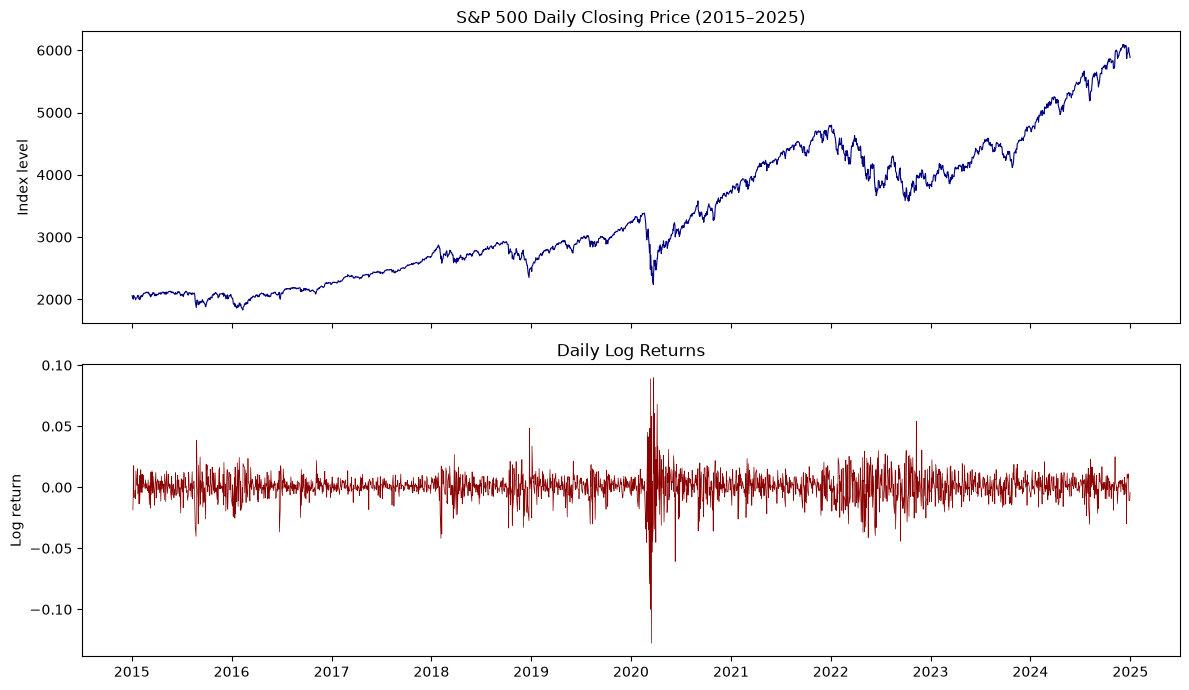

In [7]:
# Cell 4: Overview plot

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.index, df['Close'], color='navy', linewidth=0.8)
axes[0].set_title('S&P 500 Daily Closing Price (2015–2025)')
axes[0].set_ylabel('Index level')

axes[1].plot(df.index, df['log_return'], color='darkred', linewidth=0.5)
axes[1].set_title('Daily Log Returns')
axes[1].set_ylabel('Log return')
plt.tight_layout()
plt.savefig(OUTPUT_PATH_figures + 'q2_fig1_overview.png', dpi=150)
plt.show()

###  Figure caption and accompanying note

Figure 2.1 — S&P 500 daily closing price (top) and daily log returns (bottom), January 2015 – December 2024.

Figure 2.1 illustrates the key temporal properties of the series. The price level (top) shows a strong upward trend punctuated by three major drawdowns: the late-2018 correction, the COVID-19 crash of March 2020, and the 2022 bear market. The log returns (bottom) fluctuate around zero but with clearly time-varying dispersion — extended calm periods such as 2017 contrast with concentrated bursts of extreme movement in 2020 and 2022. This clustering of volatility, alongside the heavy-tailed distribution reported in Table 2.1, indicates conditional heteroscedasticity in the returns and directly motivates the GARCH modelling in Section 2.4.

### Forecasting targets
- **Models (ARIMA / LSTM / XGBoost):** next-day closing price, one-step-ahead (h=1), evaluated with MAE / RMSE / MAPE
- **GARCH(1,1):** one-day-ahead conditional variance of daily log returns

# Time Series Decomposition

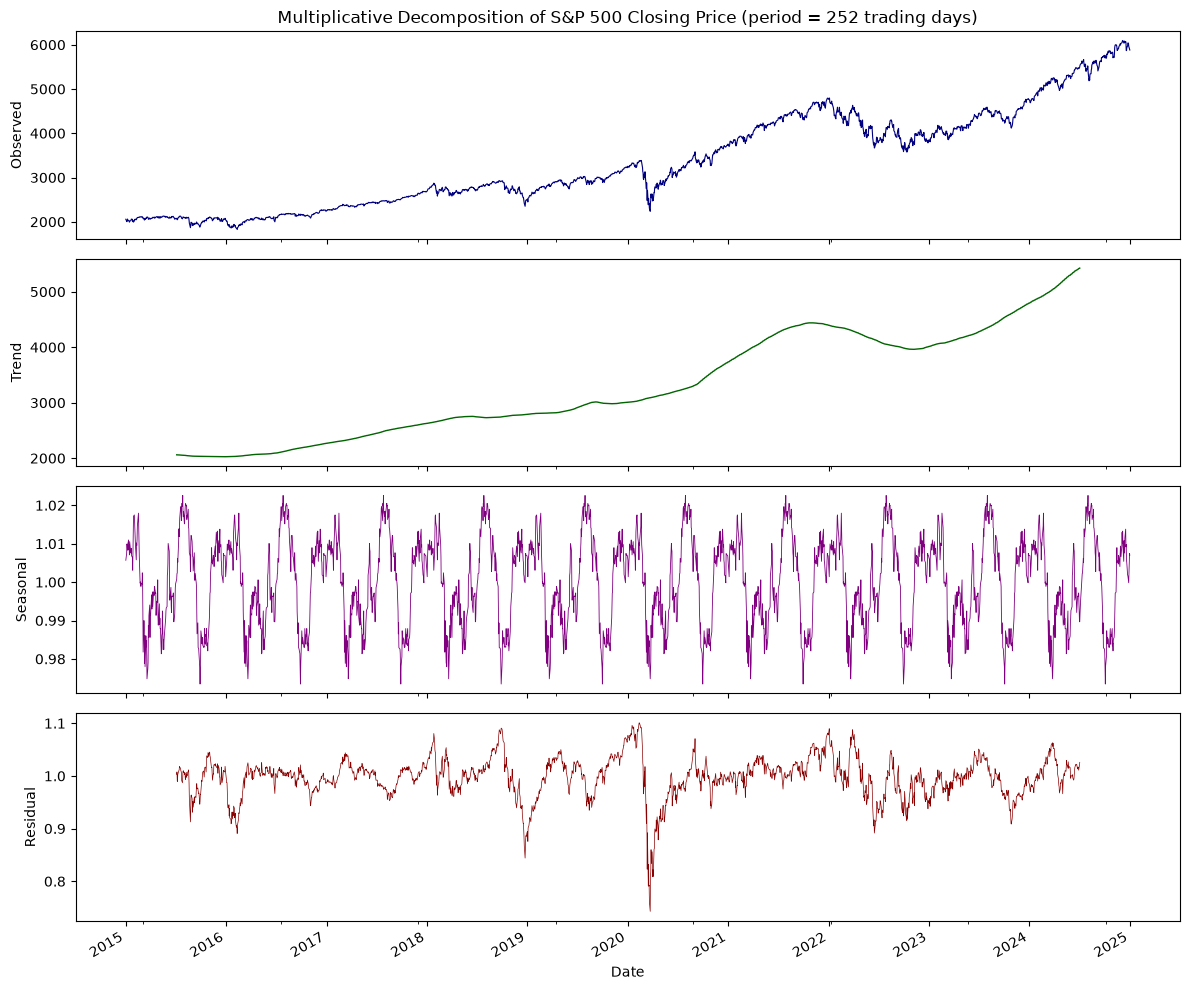

Seasonal component range: 0.0491 (4.91% peak-to-trough around trend)
Residual std: 0.0386


In [8]:
# Cell 5: Seasonal decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the closing price
# period=252 = one trading year (annual cycle at daily frequency)
# model='multiplicative' because the magnitude of fluctuations grows with the price level (visible in Fig 2.1)
decomposition = seasonal_decompose(
    df['Close'],
    model='multiplicative',
    period=252
)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='navy', linewidth=0.8)
axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='darkgreen', linewidth=1)
axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='purple', linewidth=0.6)
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], color='darkred', linewidth=0.5)
axes[3].set_ylabel('Residual')
axes[0].set_title('Multiplicative Decomposition of S&P 500 Closing Price (period = 252 trading days)')
plt.tight_layout()
plt.savefig(OUTPUT_PATH_figures + 'q2_fig2_decomposition.png', dpi=150)
plt.show()

# How much variation does each component explain?
seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
print(f"Seasonal component range: {seasonal_range:.4f} "
      f"({seasonal_range*100:.2f}% peak-to-trough around trend)")
print(f"Residual std: {decomposition.resid.std():.4f}")

# Missing values, Anomalies, and Outliers

MISSING VALUES
Close         0
High          0
Low           0
Open          0
Volume        0
log_return    1
dtype: int64

Calendar days in range: 3652
Trading days in data:   2516
Non-trading days (weekends/holidays): 1136

OUTLIER DETECTION - daily log returns
Days with |z| > 3: 36 (1.43% of observations)
Expected under normality: 6.8 days (0.27%)

Top 10 most extreme daily moves:
  2020-03-16: -0.1277
  2020-03-12: -0.0999
  2020-03-24: +0.0897
  2020-03-13: +0.0888
  2020-03-09: -0.0790
  2020-04-06: +0.0680
  2020-06-11: -0.0608
  2020-03-26: +0.0605
  2020-03-17: +0.0582
  2020-03-18: -0.0532


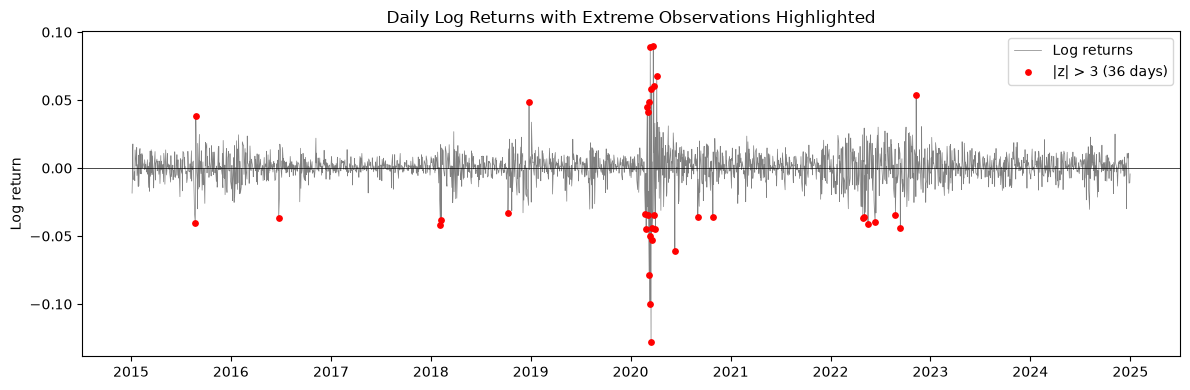

In [9]:
# Cell 6: Missing values, Anomalies, and Outliers

# --- 1. Missing values ---
print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
print(df.isna().sum())

# Calendar gaps: trading days vs calendar days
calendar_days = (df.index.max() - df.index.min()).days + 1
print(f"\nCalendar days in range: {calendar_days}")
print(f"Trading days in data:   {len(df)}")
print(f"Non-trading days (weekends/holidays): {calendar_days - len(df)}")

# --- 2. Outlier detection on log returns (z-score method) ---
print("\n" + "=" * 55)
print("OUTLIER DETECTION - daily log returns")
print("=" * 55)
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
z = (log_ret - log_ret.mean()) / log_ret.std()

outliers = log_ret[np.abs(z) > 3]
print(f"Days with |z| > 3: {len(outliers)} "
      f"({len(outliers)/len(log_ret)*100:.2f}% of observations)")
print(f"Expected under normality: {0.0027*len(log_ret):.1f} days (0.27%)")

# Top 10 most extreme days - do they cluster around known events?
print("\nTop 10 most extreme daily moves:")
top10 = log_ret.reindex(np.abs(z).sort_values(ascending=False).index[:10])
for date, ret in top10.items():
    print(f"  {date.date()}: {ret:+.4f}")

# --- 3. Visualise outliers in context ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(log_ret.index, log_ret, color='grey', linewidth=0.5, label='Log returns')
ax.scatter(outliers.index, outliers, color='red', s=15, zorder=3,
           label=f'|z| > 3 ({len(outliers)} days)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Daily Log Returns with Extreme Observations Highlighted')
ax.set_ylabel('Log return')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH_figures + 'q2_fig3_outliers.png', dpi=150)
plt.show()

# Stationarity Testing (ADF + KPSS)

In [10]:
# Cell 7: Stationarity Testing (ADF + KPSS)

from statsmodels.tsa.stattools import adfuller, kpss

def run_stationarity_tests(series, name):
    """ADF (H0: unit root / non-stationary) and
    KPSS (H0: stationary) - opposite null hypotheses."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    print(f"--- {name} ---")
    print(f"ADF  statistic: {adf_stat:8.4f}   p-value: {adf_p:.4f}   "
          f"{'STATIONARY (reject H0)' if adf_p < 0.05 else 'NON-STATIONARY (fail to reject H0)'}")
    print(f"KPSS statistic: {kpss_stat:8.4f}   p-value: {kpss_p:.4f}   "
          f"{'NON-STATIONARY (reject H0)' if kpss_p < 0.05 else 'STATIONARY (fail to reject H0)'}")
    print()

log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()

run_stationarity_tests(df['Close'], "Closing price (level)")
run_stationarity_tests(log_ret, "Daily log returns")

--- Closing price (level) ---
ADF  statistic:   0.4489   p-value: 0.9832   NON-STATIONARY (fail to reject H0)
KPSS statistic:   7.5015   p-value: 0.0100   NON-STATIONARY (reject H0)

--- Daily log returns ---
ADF  statistic: -15.7259   p-value: 0.0000   STATIONARY (reject H0)
KPSS statistic:   0.0495   p-value: 0.1000   STATIONARY (fail to reject H0)



/var/folders/36/zhxp9sss1_qdm0bgshfktl2r0000gn/T/ipykernel_1364/3097994821.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/36/zhxp9sss1_qdm0bgshfktl2r0000gn/T/ipykernel_1364/3097994821.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')


# Temporal Feature Engineering

In [11]:
# Cell 8: Temporal feature engineering

# Work on a fresh copy; create log_return formally here
data = df[['Close', 'High', 'Low', 'Open', 'Volume']].copy()
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))

# --- 1. Lag variables ---
# Past values of price and returns as predictors
for lag in [1, 2, 3, 5, 10]:
    data[f'close_lag_{lag}'] = data['Close'].shift(lag)
    data[f'return_lag_{lag}'] = data['log_return'].shift(lag)

# --- 2. Rolling statistics ---
# 5 days = 1 trading week, 21 days = 1 trading month
for window in [5, 10, 21]:
    data[f'roll_mean_{window}'] = data['Close'].rolling(window).mean()
    data[f'roll_std_{window}'] = data['Close'].rolling(window).std()

# Rolling volatility of returns (realised volatility proxies)
data['ret_vol_5'] = data['log_return'].rolling(5).std()
data['ret_vol_21'] = data['log_return'].rolling(21).std()

# Momentum: % change over the past week / month
data['momentum_5'] = data['Close'].pct_change(5)
data['momentum_21'] = data['Close'].pct_change(21)

# --- 3. Seasonal / calendar indicators ---
data['day_of_week'] = data.index.dayofweek      # 0=Mon ... 4=Fri
data['month'] = data.index.month                # 1-12
data['quarter'] = data.index.quarter            # 1-4

# --- 4. Target: next-day closing price (one-step-ahead) ---
data['target_close_t+1'] = data['Close'].shift(-1)

# --- 5. Drop rows lost to lags/rolling windows and the final row (no target) ---
rows_before = len(data)
data = data.dropna()
print(f"Rows before dropna: {rows_before}")
print(f"Rows after dropna:  {len(data)} "
      f"(lost {rows_before - len(data)}: first 21 to rolling windows/lags, last 1 to target shift)")
print(f"Features created: {len(data.columns)} columns")
print(f"\nDate range after feature engineering: "
      f"{data.index.min().date()} to {data.index.max().date()}")

# --- 6. Save processed dataset ---
data.to_csv(os.path.join(DATA_PATH_processed, "data_cleaned.csv"))
print(f"\nSaved: {os.path.join(DATA_PATH_processed, 'data_cleaned.csv')}")
data.head(3)

Rows before dropna: 2516
Rows after dropna:  2494 (lost 22: first 21 to rolling windows/lags, last 1 to target shift)
Features created: 30 columns

Date range after feature engineering: 2015-02-03 to 2024-12-30

Saved: /Users/chamika/Desktop/git/machine_learning/Question_2/data/processed/data_cleaned.csv


,Close,High,Low,Open,Volume,log_return,close_lag_1,return_lag_1,close_lag_2,return_lag_2,...,roll_mean_21,roll_std_21,ret_vol_5,ret_vol_21,momentum_5,momentum_21,day_of_week,month,quarter,target_close_t+1
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-03,2050.030029,2050.300049,2022.709961,2022.709961,4615900000,0.014336,2020.849976,0.012879,1994.989990,-0.013077,...,2027.440488,20.987774,0.014115,0.011401,0.010091,-0.003969,1,2,1,2041.510010
2015-02-04,2041.510010,2054.739990,2036.719971,2048.860107,4141920000,-0.004165,2050.030029,0.014336,2020.849976,0.012879,...,2028.437157,21.142088,0.011980,0.010659,0.019654,0.010358,2,2,1,2062.520020
2015-02-05,2062.520020,2063.550049,2043.449951,2043.449951,3821990000,0.010239,2041.510010,-0.004165,2050.030029,0.014336,...,2031.290016,21.521433,0.012071,0.010632,0.020418,0.029916,3,2,1,2055.469971
